In [4]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
import scipy.sparse as sp


In [15]:
#参数
dela = 1
t = 38 * dela
af = 400/0.1875* dela * 10**(-10)
a = 10**(-10)*(400/3)
mu = 8 * dela
U = 1.9 * dela
mz = 7 * dela
h = 1.2 * np.sqrt(mu**2 + dela**2)
L = 11
chaodaojiao = np.pi/10
saimanjiao = np.pi / 4

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.eye(2, dtype=complex)

#左边矩阵信息
HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy
Delta_L=dela * np.exp(1j*chaodaojiao/2) * 1j * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
    ])

#中间矩阵信息
H_center_to_L=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_center_block=(U-mu+2*t)*s0+mz*sz
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    
H_center_right_to_left_hop=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_R_to_center=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])

#右边矩阵信息
HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy
Delta_R=dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
H_R_right_to_left_hop=np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])


In [ ]:

def build_block_hamiltonian(
    Lpot, centerpot, Rpot,
    H_L_onsite, H_center, H_R,
    H_L_right_to_left_hop,
    H_center_right_to_left_hop,
    H_R_right_to_left_hop,
    H_center_to_L,
    H_R_to_center
):

    N = Lpot + centerpot + Rpot
    dim = 4 * N
    H = np.zeros((dim, dim), dtype=complex)

    def set_block(i, j, block):
        H[4*i:4*(i+1), 4*j:4*(j+1)] = block

    # ========= 对角块 =========
    for i in range(N):
        if i < Lpot:
            set_block(i, i, H_L_onsite)
        elif i < Lpot + centerpot:
            set_block(i, i, H_center)
        else:
            set_block(i, i, H_R)

    # ========= 区内 hopping =========
    for i in range(N - 1):

        # Left 区
        if i < Lpot - 1:
            set_block(i, i+1, H_L_right_to_left_hop)
            set_block(i+1, i, H_L_right_to_left_hop.conj().T)

        # Center 区
        elif Lpot <= i < Lpot + centerpot - 1:
            set_block(i, i+1, H_center_right_to_left_hop)
            set_block(i+1, i, H_center_right_to_left_hop.conj().T)

        # Right 区
        elif i >= Lpot + centerpot:
            set_block(i, i+1, H_R_right_to_left_hop)
            set_block(i+1, i, H_R_right_to_left_hop.conj().T)

    # ========= 区域连接 hopping =========

    # L <-> Center
    i = Lpot - 1
    set_block(i, i+1, H_center_to_L)
    set_block(i+1, i, H_center_to_L.conj().T)

    # Center <-> R
    i = Lpot + centerpot - 1
    set_block(i, i+1, H_R_to_center)
    set_block(i+1, i, H_R_to_center.conj().T)

    return H

def hamiltonian_saiman(saimanjiao,chaodaojiao):
    HR_block = -(mu-2*t)*s0 \
        + h*np.cos(saimanjiao)*sx \
        + h*np.sin(saimanjiao)*sy

    Delta_R = dela * np.exp(-1j*chaodaojiao/2) * 1j * sy

    H_R_onsite = np.block([
        [ HR_block,           Delta_R ],
        [ Delta_R.conj().T,  -HR_block.conj() ]
    ])

    H_R_right_to_left_hop_block = -1*(t*s0 + 1j*af/a*sz)
    H_R_right_to_left_hop = np.block([
        [ H_R_right_to_left_hop_block,              np.zeros((2,2)) ],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])


    phase_L = np.exp(+1j * chaodaojiao / 2)
    phase_R = np.exp(-1j * chaodaojiao / 2)

    H_center_to_L_phi = phase_L * H_center_to_L
    H_R_to_center_phi = phase_R * H_R_to_center


    H_total = build_block_hamiltonian(
        Lpot, centerpot, Rpot,
        H_L_onsite, H_center, H_R_onsite,
        H_L_right_to_left_hop,
        H_center_right_to_left_hop,
        H_R_right_to_left_hop,
        H_center_to_L,
        H_R_to_center
    )

    return H_total


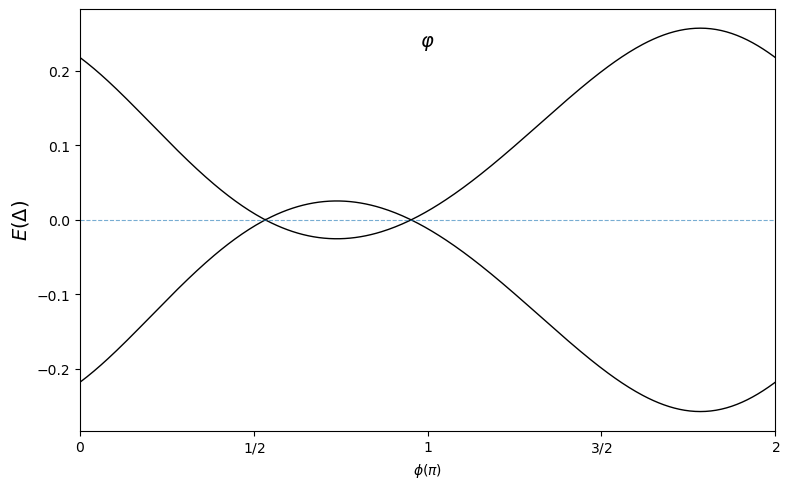

In [16]:
num_levels = 2     # 只要 2 条低能态
energies = []
# 计算能带参数
Lpot=Rpot =10
centerpot=10
num_points = 400
saimanjiao_array = np.linspace(0, 2*np.pi, num_points)

for saimanjiao in saimanjiao_array:
    H = hamiltonian_saiman(saimanjiao,chaodaojiao)

    Hs = sp.csc_matrix(H)

    ev = eigsh(
        Hs,
        k=num_levels,
        sigma=0,               # 锁定 E≈0
        return_eigenvectors=False
    )

    energies.append(np.sort(ev))

energies = np.array(energies)
plt.figure(figsize=(8,5))

for n in range(energies.shape[1]):
    plt.plot(saimanjiao_array, energies[:, n], 'k-', lw=1)

plt.xlabel(r'$\phi(\pi)$')
plt.ylabel(r'$E(\Delta)$', fontsize=14)
plt.xlim(0, 2*np.pi)
#plt.ylim(-0.3, 0.3)

plt.xticks(
    [0, np.pi/2, np.pi,  3*np.pi/2, 2*np.pi],
    ['0', r'$1/2$', r'$1$', r'$3/2$',r'$2$']
)
plt.text(
    0.5, 0.92,                 # (x, y) 在轴坐标中的位置
    r'$\varphi $',
    transform=plt.gca().transAxes,
    ha='center',
    va='center',
    fontsize=14
)
plt.axhline(0, ls='--', lw=0.8, alpha=0.6)
plt.tight_layout()
plt.show()



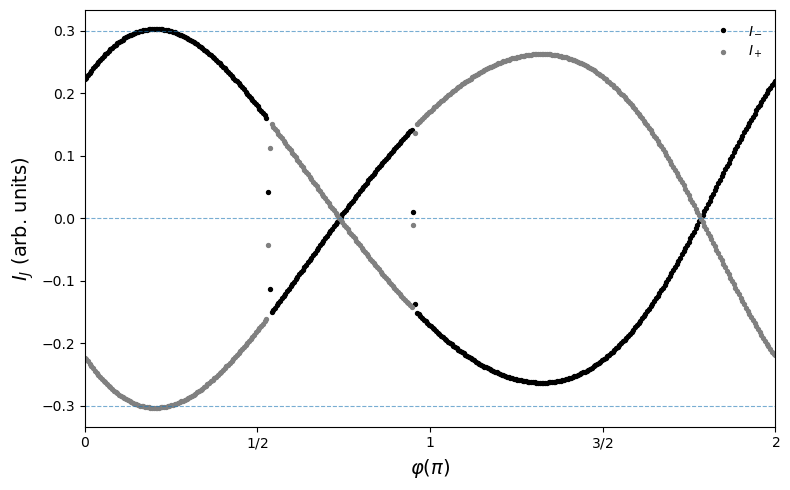

In [154]:
# energies: shape (N_phi, 2)

E_minus = np.min(energies, axis=1)   # 每个 φ 的负能
E_plus  = np.max(energies, axis=1)   # 每个 φ 的正能
prefactor = 2.0     # 2e / ħ（你当前无量纲单位）
dphi = saimanjiao_array[1] - saimanjiao_array[0]

I_minus = prefactor * np.gradient(E_minus, dphi)
I_plus  = prefactor * np.gradient(E_plus,  dphi)
plt.figure(figsize=(8, 5))

plt.scatter(
    saimanjiao_array,
    I_minus,
    s=8,
    c='k',
    label=r'$I_-$'
)

plt.scatter(
    saimanjiao_array,
    I_plus,
    s=8,
    c='gray',
    label=r'$I_+$'
)

plt.xlabel(r'$\varphi(\pi)$', fontsize=14)
plt.ylabel(r'$I_J$ (arb. units)', fontsize=14)

plt.xlim(0, 2*np.pi)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$1/2$', r'$1$', r'$3/2$', r'$2$']
)

plt.axhline(-0.3, ls='--', lw=0.8, alpha=0.6)
plt.axhline(0, ls='--', lw=0.8, alpha=0.6)
plt.axhline(0.3, ls='--', lw=0.8, alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


